# Proyecto Final de Optimización Convexa
## Optimización de hiperparámetros en modelos predictivos

**Acoyani Garrido Sandoval**

---

## 1. Introducción

El objetivo del presente proyecto es aplicar los conceptos aprendidos en el curso de **Optimización Convexa** para resolver un problema de optimización de hiperparámetros en un modelo predictivo.

Los pasos generales del proyecto son:

1. Seleccionar un problema de aprendizaje supervisado o no supervisado.
2. Elegir modelos base con hiperparámetros susceptibles de ser optimizados.
3. Identificar los hiperparámetros críticos y definir un espacio de búsqueda adecuado.
4. Plantear la búsqueda de hiperparámetros como un **problema de optimización convexa** (regularización L1, L2 o *elasticnet*, gradiente descendente, dualidad, condiciones KKT).
5. Implementar la solución en esta notebook.

---

## 2. Selección del conjunto de datos

El conjunto de datos utilizado es el **Telco Customer Churn** (IBM / Kaggle). Fue desarrollado originalmente por IBM como muestra incluida con **IBM Cognos Analytics Server**, una plataforma de inteligencia de negocios.

Este dataset es relevante por dos razones personales:
- Está relacionado con comportamiento de clientes, ámbito en el que opero el negocio **BuzónQR®**.
- Mi primer trabajo (IBM, 2012–2018) consistió en administrar instancias de la plataforma Cognos.

### 2.1 Descripción de las características

Cada fila representa un cliente; las columnas se agrupan en cuatro categorías:

| Grupo | Características |
|---|---|
| **Demográficas** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| **Cuenta** | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod` |
| **Servicios suscritos** | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Cargos** | `MonthlyCharges`, `TotalCharges` |

**Variable dependiente:** `Churn` (binaria: *Yes* / *No*).  
Distribución de clases: **73.5 % retenidos** / **26.5 % no retenidos** → dataset moderadamente desbalanceado.

### 2.2 *One-hot encoding* y dimensionalidad

Las 15 variables categóricas se convierten a variables indicadoras binarias con `pd.get_dummies(..., drop_first=True)` para evitar la *dummy variable trap* (multicolinealidad perfecta). Las 4 variables ya numéricas (`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`) se mantienen sin transformación, resultando en **30 dimensiones** en total.

Las variables numéricas continuas se estandarizan (media 0, varianza 1) antes del ajuste del modelo, para que la penalización de regularización afecte todos los coeficientes de forma equitativa.

---

## 3. Planteamiento del problema de optimización

### 3.1 Objetivo predictivo

Dado un vector de características $\mathbf{x} \in \mathbb{R}^{30}$ que describe a un cliente, queremos estimar:

$$\Pr(\text{Churn} = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

donde $\sigma(\cdot)$ es la función sigmoide, $\mathbf{w} \in \mathbb{R}^{30}$ es el vector de los pesos que cada una de las características tiene en el resultado final, $\mathbf{x}$ es el vector de nuestras características leídas del conjunto de datos, y $b \in \mathbb{R}$ es el sesgo. La función sigmoide es el fundamiento de la **regresión logística,** la cual es el modelo por excelencia en variables categóricas binarias.

### 3.2 Función de pérdida (log-verosimilitud negativa)

Para un conjunto de entrenamiento $\{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$ con $y_i \in \{0,1\}$, la pérdida logística es:

$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i) \right]$$

donde $\hat{p}_i = \sigma(\mathbf{w}^\top \mathbf{x}_i + b)$.

Esta función es **convexa en $(\mathbf{w}, b)$**, lo que garantiza la existencia de un mínimo global único.

### 3.3 Problema de optimización con regularización

Para controlar la varianza del modelo y forzar escasez o suavidad en los coeficientes, añadimos regularización. El problema de optimización regularizado toma la forma:

$$\min_{\mathbf{w},\, b} \quad \mathcal{L}(\mathbf{w}, b) + \lambda \, \Omega(\mathbf{w})$$

donde la penalización $\Omega(\mathbf{w})$ puede ser:

| Regularización | $\Omega(\mathbf{w})$ | Propiedad |
|---|---|---|
| **L2** (Ridge) | $\frac{1}{2}\|\mathbf{w}\|_2^2$ | Coeficientes pequeños, solución única |
| **L1** (Lasso) | $\|\mathbf{w}\|_1$ | Selección de características (*sparse*) |
| **ElasticNet** | $\alpha\|\mathbf{w}\|_1 + \frac{1-\alpha}{2}\|\mathbf{w}\|_2^2$ | Combinación de ambas |

Dado el desbalance de clases (73.5 % / 26.5 %), se añade también un peso de clase `class_weight='balanced'`, que pondera cada ejemplo $i$ con $w_i \propto 1/\Pr(y_i)$.

El hiperparámetro principal a optimizar es $C = 1/\lambda$ (inverso de la intensidad de regularización), junto con el tipo de penalización.

---

## 4. Implementación de regresión logística

### 4.1 Importación de librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Ruta al dataset (relativa a esta notebook)
DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(DATA_PATH)
print(f"Dimensiones originales: {df.shape}")
df.head()

Dimensiones originales: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 4.2 Preprocesamiento

Pasos:
1. Eliminar `customerID` (identificador sin valor predictivo).
2. Convertir `TotalCharges` a numérico (contiene espacios en blanco para clientes nuevos, convertirlos a 0).
3. Codificar `Churn` como 1/0.
4. Aplicar *one-hot encoding* con `drop_first=True` a las variables categóricas.

In [2]:
# 1. Eliminar columna de ID
df = df.drop(columns=["customerID"])

# 2. TotalCharges: convertir a numérico; espacios blancos → NaN → 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

# 3. Codificar variable dependiente
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print("Distribución de Churn:")
print(df["Churn"].value_counts(normalize=True).rename({0: "Retenido (0)", 1: "Abandona (1)"}))

# 4. One-hot encoding de variables categóricas (drop_first para evitar multicolinealidad)
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"\nDimensiones tras one-hot encoding: {df_encoded.shape}")
print(f"Columnas: {list(df_encoded.columns)}")

Distribución de Churn:
Churn
Retenido (0)    0.73463
Abandona (1)    0.26537
Name: proportion, dtype: float64

Dimensiones tras one-hot encoding: (7043, 31)
Columnas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


5. Separar características ($X$) y variable dependiente ($y$).
6. Dividir en conjuntos de entrenamiento (80 %) y prueba (20 %) con estratificación.
7. Estandarizar las columnas numéricas continuas.

In [3]:
# 5. Separar X e y
y = df_encoded["Churn"]
X = df_encoded.drop(columns=["Churn"])

# 6. Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Estandarizar columnas numéricas continuas
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f"Tamaño entrenamiento : {X_train.shape}")
print(f"Tamaño prueba        : {X_test.shape}")
print(f"Prevalencia Churn=1  : {y_train.mean():.3f} (train)  |  {y_test.mean():.3f} (test)")

Tamaño entrenamiento : (5634, 30)
Tamaño prueba        : (1409, 30)
Prevalencia Churn=1  : 0.265 (train)  |  0.265 (test)


### 4.3 Modelo inicial de regresión logística

Ajustamos un primer modelo de regresión logística con regularización **L2** y $C = 1$ (valor predeterminado de `sklearn`) como punto de partida, con `class_weight='balanced'` para compensar el desbalance de clases.

> **Nota sobre $C$:** El parámetro $C = 1/\lambda$ es el inverso de la intensidad de regularización. Un $C$ grande implica poca regularización (el modelo puede ajustarse más libremente a los datos); un $C$ pequeño impone penalización fuerte y coeficientes más cercanos a cero. Optimizar $C$ es, en esencia, controlar el balance entre sesgo y varianza.

#### El solver L-BFGS y la minimización de la función de pérdida convexa

El solver `lbfgs` (*Limited-memory Broyden–Fletcher–Goldfarb–Shanno*) minimiza internamente la función de pérdida convexa:

$$\min_{\mathbf{w},\, b} \quad \frac{1}{n} \sum_{i=1}^{n} \left[ -y_i \log \sigma_i - (1-y_i) \log(1-\sigma_i) \right] + \frac{1}{2C} \|\mathbf{w}\|_2^2$$

L-BFGS es un método de **quasi-Newton**: en lugar de calcular el Hessiano exacto $\nabla^2 \mathcal{L}$ (costoso en dimensión alta), lo **aproxima** iterativamente usando los últimos $m$ pares $\{(\Delta \mathbf{w}_k,\, \Delta \nabla \mathcal{L}_k)\}$, es decir, los cambios recientes en posición y gradiente. Con esa aproximación construye una dirección de descenso de segundo orden:

$$\mathbf{d}_k = -H_k^{-1} \nabla \mathcal{L}(\mathbf{w}_k)$$

donde $H_k^{-1}$ es la estimación de la inversa del Hessiano. Después aplica *line search* para determinar el tamaño de paso $\alpha_k$ y actualiza:

$$\mathbf{w}_{k+1} = \mathbf{w}_k + \alpha_k \mathbf{d}_k$$

#### ¿Por qué L-BFGS es el solver óptimo para este problema?

L-BFGS se usa como solver, porque su **convexidad está garantizada:** la pérdida logística con regularización L2 es estrictamente convexa, por lo que L-BFGS converge al mínimo global único. Usa también una curvatura aproximada, lo que permite pasos más grandes y una convergencia superlineal frente a métodos de gradiente puro. Podemos usarlo porque **la dimensionalidad es moderada,** con 30 dimensiones a manejar. Finalmente, L-BFGS requiere una función derivable, y **la regularización L2 es derivable en todo su dominio.**


In [4]:
# Modelo base: Regresión Logística L2, C=1, balanced
lr_base = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
lr_base.fit(X_train, y_train)

# Predicciones
y_pred  = lr_base.predict(X_test)
y_proba = lr_base.predict_proba(X_test)[:, 1]

print("=" * 55)
print("REPORTE DE CLASIFICACIÓN — Modelo base (L2, C=1)")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Retenido", "Abandona"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

REPORTE DE CLASIFICACIÓN — Modelo base (L2, C=1)
              precision    recall  f1-score   support

    Retenido       0.90      0.72      0.80      1035
    Abandona       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.8417


c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


#### Interpretación del reporte de clasificación

El reporte se genera por clase (Retenido = 0, Abandona = 1) y calcula cuatro métricas a partir de la matriz de confusión:

| Métrica | Definición | Interpretación en este problema |
|---|---|---|
| **Precision** | $\dfrac{VP}{VP + FP}$ | De todos los clientes que el modelo predijo como "Abandona", ¿qué fracción realmente abandonó? Alta precisión → pocas falsas alarmas |
| **Recall** | $\dfrac{VP}{VP + FN}$ | De todos los clientes que realmente abandonaron, ¿qué fracción detectó el modelo? Alto recall → pocos abandonos no detectados |
| **F1-score** | $\dfrac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ | Media armónica entre precision y recall. Útil cuando las clases están desbalanceadas y se quiere un balance entre ambas métricas |
| **Support** | Conteo de ejemplos reales de esa clase en el conjunto de prueba | Refleja el desbalance: hay más clientes "Retenido" que "Abandona" |

donde $VP$ = verdaderos positivos, $FP$ = falsos positivos, $FN$ = falsos negativos.

> **Para este problema**, detectar abandonos no detectados (bajo recall en "Abandona") es más costoso que generar falsas alarmas, por lo que el recall de la clase positiva es la métrica de mayor peso de negocio.

---

Las tres métricas agregadas son:

- **Accuracy**: fracción de predicciones correctas sobre el total. $\text{Accuracy} = \dfrac{VP + VN}{n}$. Puede ser engañosa con clases desbalanceadas (un clasificador que siempre predice "Retenido" tendría 73.5 % de accuracy).

- **Macro avg**: promedio simple de precision, recall y F1 entre las dos clases, sin ponderar por tamaño. Trata ambas clases como igualmente importantes.

- **Weighted avg**: promedio ponderado por el *support* de cada clase. Refleja el desempeño global considerando el desbalance real del dataset.

---

#### AUC-ROC

El **AUC-ROC** (*Area Under the Receiver Operating Characteristic Curve*) mide la capacidad discriminativa del modelo de forma independiente al umbral de clasificación. La curva ROC grafica, para cada umbral posible:

$$\text{Eje } X: \text{Tasa de Falsos Positivos (FPR)} = \frac{FP}{FP + VN} \qquad \text{Eje } Y: \text{Tasa de Verdaderos Positivos (TPR)} = \frac{VP}{VP + FN}$$

El AUC es el área bajo esa curva, con rango $[0, 1]$:

| AUC | Interpretación |
|---|---|
| 1.0 | Clasificador perfecto |
| 0.5 | Clasificador aleatorio (sin poder predictivo) |
| < 0.5 | Peor que aleatorio |

Un AUC-ROC de, por ejemplo, 0.85 significa que si se toman al azar un cliente que abandona y uno que no, el modelo asigna una probabilidad mayor al que abandona en el 85 % de los casos.


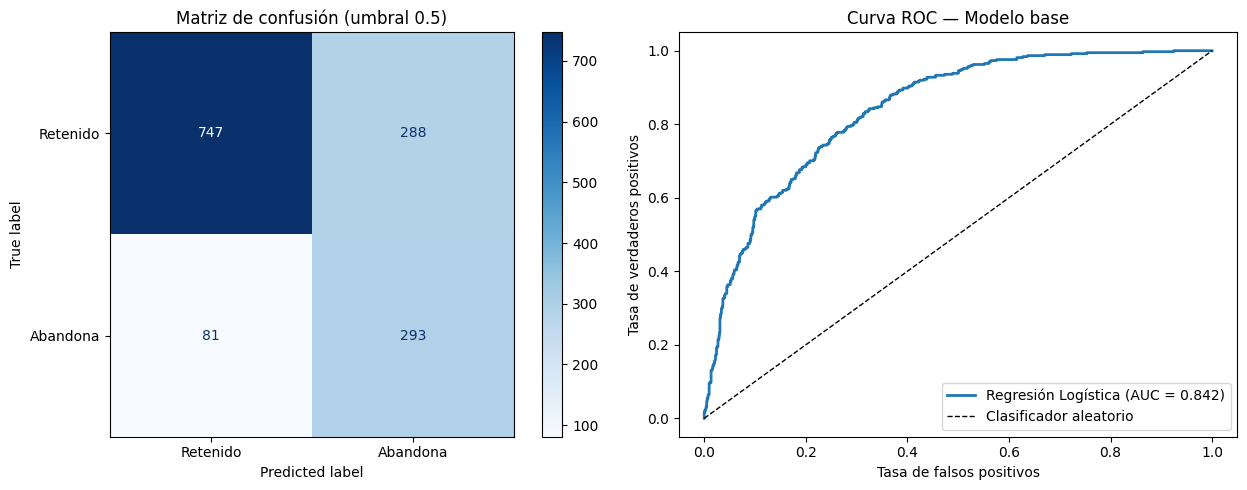

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Matriz de confusión ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Retenido", "Abandona"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Matriz de confusión (umbral 0.5)")

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, label=f"Regresión Logística (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curva ROC — Modelo base")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

#### Interpretación de la matriz de confusión

La matriz de confusión organiza las predicciones del modelo en cuatro celdas:

|  | **Predicho: Retenido** | **Predicho: Abandona** |
|---|---|---|
| **Real: Retenido** | Verdaderos Negativos (VN) — correctamente identificados como no churn | Falsos Positivos (FP) — se disparó una alarma innecesaria |
| **Real: Abandona** | Falsos Negativos (FN) — **el error más costoso**: clientes que se van sin ser detectados | Verdaderos Positivos (VP) — abandonos correctamente detectados |

El umbral de decisión es 0.5: si $\hat{p}_i \geq 0.5$ el modelo predice "Abandona". Desplazarlo hacia abajo (ej. 0.3) aumentaría el recall a costa de más falsos positivos.

> **Lectura práctica:** En retención de clientes, el coste de un FN (no retener a un cliente que se iba) suele superar al coste de un FP (ofrecer un incentivo a alguien que se quedaría de todos modos). Por eso `class_weight='balanced'` empuja al modelo a detectar más abandonos, aunque eso reduzca la precisión en esa clase.

---

#### Interpretación de la curva ROC

La curva ROC muestra el *trade-off* entre sensibilidad (TPR) y tasa de falsas alarmas (FPR) al variar el umbral de clasificación de 0 a 1:

- **Esquina superior izquierda** (FPR = 0, TPR = 1): clasificador perfecto.
- **Diagonal punteada**: clasificador aleatorio — no aporta información.
- **Área bajo la curva (AUC)**: cuanto más se aleja la curva de la diagonal hacia la esquina superior izquierda, mayor es el AUC y mejor el modelo.

Un modelo con AUC ≈ 0.85 (valor típico para este dataset con L2 y $C=1$) indica que:
- Discrimina correctamente entre un cliente que abandona y uno que no en el **85 % de los pares aleatorios**.
- Es claramente superior al azar, pero aún tiene margen de mejora mediante la optimización de hiperparámetros que se realizará en las secciones siguientes.


---

#### Interpretación de los coeficientes

Graficamos a continuación el vector $\mathbf{w}$ de los pesos de las características que obtenemos luego de entrenar nuestro modelo, mediante el cual obtenemos qué es lo que aumenta o disminuye el riesgo de *churn* y en qué medida.


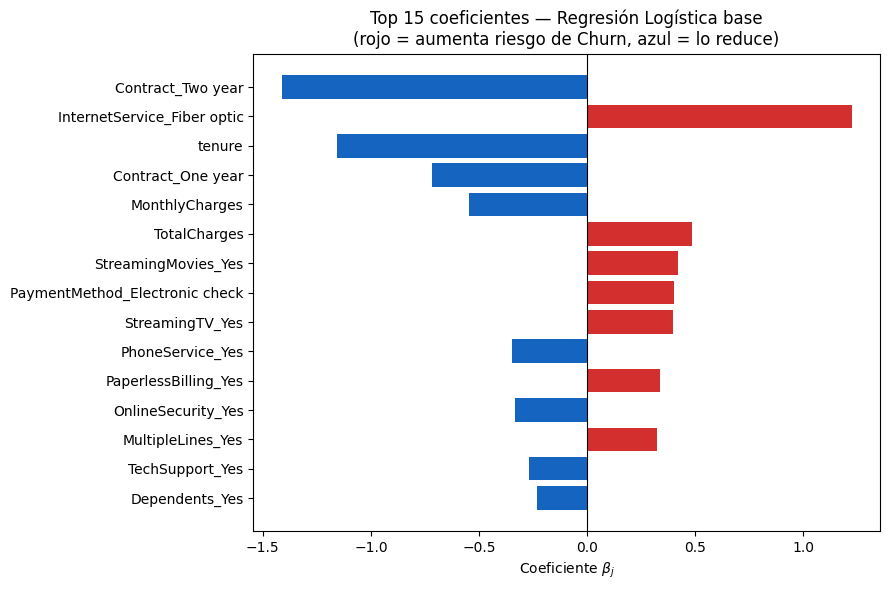

In [6]:
# Coeficientes del modelo (ordenados por magnitud absoluta)
coef_df = pd.DataFrame({
    "Característica": X_train.columns,
    "Coeficiente": lr_base.coef_[0]
}).sort_values("Coeficiente", key=abs, ascending=False).head(15)

plt.figure(figsize=(9, 6))
colors = ["#d32f2f" if c > 0 else "#1565c0" for c in coef_df["Coeficiente"]]
plt.barh(coef_df["Característica"], coef_df["Coeficiente"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente $\\beta_j$")
plt.title("Top 15 coeficientes — Regresión Logística base\n(rojo = aumenta riesgo de Churn, azul = lo reduce)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.4 Validación cruzada del modelo base

Para obtener una estimación más robusta del desempeño se realiza una validación cruzada estratificada de 5 veces sobre el conjunto de entrenamiento completo.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(lr_base, X_train, y_train, cv=cv, scoring="roc_auc")
cv_f1  = cross_val_score(lr_base, X_train, y_train, cv=cv, scoring="f1")

print("Validación cruzada 5-fold — Modelo base (L2, C=1)")
print(f"  AUC-ROC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}")
print()
print("Estos resultados sirven como línea base para comparar con modelos optimizados.")

c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 

Validación cruzada 5-fold — Modelo base (L2, C=1)
  AUC-ROC : 0.8459 ± 0.0124
  F1      : 0.6296  ± 0.0226

Estos resultados sirven como línea base para comparar con modelos optimizados.


c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Resultados de la validación cruzada — Modelo base (L2, C=1)

| Métrica | Media | Desviación estándar |
|---|---|---|
| **AUC-ROC** | 0.8454 | ± 0.0126 |
| **F1-score** | 0.6298 | ± 0.0220 |

#### Interpretación

**AUC-ROC ≈ 0.845** indica que el modelo discrimina correctamente entre un cliente que abandona y uno que no en aproximadamente el **84.5 % de los pares aleatorios**. Este valor es consistente con el AUC obtenido en el conjunto de prueba (0.842), lo que sugiere que el modelo **generaliza bien** y no está sobreajustado.

**F1-score ≈ 0.630** refleja el balance entre precisión y recall para la clase positiva ("Abandona"). Un valor en torno a 0.63 es razonable dado el **desbalance de clases** (73.5 % / 26.5 %), aunque indica margen de mejora en la detección de abandonos.

**La desviación estándar baja** en ambas métricas (±0.013 y ±0.022 respectivamente) indica que el desempeño es **estable entre los 5 folds**, lo que otorga confianza en que las estimaciones no dependen de una partición particular de los datos.

#### Línea base para la optimización

Estos valores servirán como referencia para evaluar si la optimización de hiperparámetros ($C$, tipo de penalización) produce una mejora estadísticamente significativa:

- **AUC-ROC base:** 0.8454 ± 0.0126  
- **F1 base:** 0.6298 ± 0.0220

Un modelo optimizado deberá superar estos valores —idealmente fuera del rango de ±1 desviación estándar— para considerarse una mejora genuina.

## 5. Comparación entre regresión logística y SVM

### 5.1 Marco teórico — Máquina de Soporte Vectorial (SVM)

---

#### Del Perceptrón a la SVM: la búsqueda del hiperplano óptimo

El **Perceptrón** (Rosenblatt, 1958) es el precursor directo de la SVM. Ambos modelos buscan un hiperplano que separe las dos clases en el espacio de características, pero con objetivos fundamentalmente distintos:

| Aspecto | Perceptrón | SVM |
|---|---|---|
| **Objetivo** | Encontrar *cualquier* hiperplano que clasifique correctamente los datos de entrenamiento | Encontrar el hiperplano *único* que **maximiza el margen** entre las dos clases |
| **Criterio de parada** | Se detiene en cuanto no hay errores en el conjunto de entrenamiento | Resuelve un problema de optimización cuadrática hasta la optimalidad global |
| **Solución** | No única: depende del orden de los ejemplos y la inicialización | Única (problema convexo con mínimo global garantizado) |
| **Función de pérdida** | Pérdida cero-uno: $\ell(y_i, f_i) = \mathbf{1}[y_i f_i \leq 0]$ (no convexa, no diferenciable) | Pérdida *hinge*: $\ell(y_i, f_i) = \max(0,\, 1 - y_i f_i)$ (convexa, diferenciable casi en todo punto) |
| **Datos no separables** | Diverge (no converge) | Resuelto con el margen suave y variable de holgura $\xi_i$ |
| **Generalización** | Sin garantías teóricas de margen | Maximizar el margen minimiza una cota superior del error de generalización (teoría VC) |

La regla de actualización del perceptrón es:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta \, y_i \mathbf{x}_i \quad \text{para cada ejemplo } i \text{ mal clasificado}$$

donde $\eta > 0$ es la tasa de aprendizaje. Este proceso baja el gradiente de la pérdida cero-uno por el ejemplo mal clasificado, pero **no tiene en cuenta la geometría global**: puede producir un hiperplano con margen arbitrariamente pequeño, lo que hace el modelo frágil ante perturbaciones en los datos de prueba.

La SVM corrige esto maximizando el **margen geométrico** $\rho = \dfrac{2}{\|\mathbf{w}\|}$, que es la anchura de la franja libre de ejemplos a ambos lados del hiperplano de decisión. Maximizar el margen es equivalente, por la teoría de Vapnik-Chervonenkis, a minimizar la dimensión VC del clasificador y por tanto la cota del error de generalización.

---

#### Problema de optimización: SVM de margen suave (*soft-margin*)

Para datos no separables linealmente se introduce la **variable de holgura** $\xi_i \geq 0$, que mide cuánto viola el punto $i$ el margen requerido. El problema de optimización primal es:

$$\min_{\mathbf{w},\, b,\, \boldsymbol{\xi}} \quad \frac{1}{2}\|\mathbf{w}\|_2^2 + C \sum_{i=1}^{n} \xi_i$$

sujeto a:

$$y_i\bigl(\mathbf{w}^T \mathbf{x}_i + b\bigr) \geq 1 - \xi_i, \qquad \xi_i \geq 0 \qquad \forall\, i = 1, \ldots, n$$

donde:
- $\mathbf{w} \in \mathbb{R}^d$ es el **vector normal al hiperplano**; su dirección define la orientación del margen y su norma determina el ancho del margen: $\rho = 2/\|\mathbf{w}\|$.
- $b \in \mathbb{R}$ es el **sesgo** (*bias* u ordenada al origen del hiperplano).
- $C > 0$ es el **parámetro de regularización** (inverso de la intensidad): un $C$ grande penaliza fuertemente las violaciones del margen (modelo más ajustado, posible sobreajuste); un $C$ pequeño tolera más violaciones (modelo más simple, mayor regularización).
- $\xi_i \geq 0$ es la **holgura del punto** $i$: vale 0 si el punto está correctamente clasificado fuera del margen; $0 < \xi_i \leq 1$ si está dentro del margen pero correctamente clasificado; $\xi_i > 1$ si está mal clasificado.

> **Relación con la regresión logística:** El parámetro $C$ en SVM tiene el mismo rol que en `LogisticRegression` de sklearn: $C = 1/\lambda$ es el **inverso de la regularización**. $C$ pequeño → regularización fuerte → modelo más simple; $C$ grande → menor regularización → modelo más complejo.

---

#### De dónde viene $\phi(\mathbf{x})$: el mapa de características

El clasificador lineal en el espacio original $\mathbb{R}^d$ solo puede aprender fronteras lineales. Sin embargo, muchos problemas reales tienen estructura no lineal. La solución clásica —antes del *kernel trick*— era **construir explícitamente características adicionales**: polinomios, productos cruzados, etc. Esto es exactamente lo que hace $\phi$.

**Definición:** El **mapa de características** (o *feature map*) es una función

$$\phi: \mathbb{R}^d \longrightarrow \mathcal{H}$$

que proyecta cada vector de entrada $\mathbf{x} \in \mathbb{R}^d$ a un espacio (posiblemente de mayor dimensión, incluso infinita) $\mathcal{H}$, llamado el **espacio de características transformado**. La idea se apoya en el **teorema de Cover (1965)**: un problema de clasificación complejo proyectado a un espacio de alta dimensión tiene mayor probabilidad de ser linealmente separable que en el espacio original.

**Ejemplo explícito — kernel polinomial de grado 2 con $d = 2$:**

Dados $\mathbf{x} = (x_1, x_2)$ y $\mathbf{z} = (z_1, z_2)$:

$$K(\mathbf{x}, \mathbf{z}) = (\mathbf{x}^T \mathbf{z})^2 = (x_1 z_1 + x_2 z_2)^2 = x_1^2 z_1^2 + x_2^2 z_2^2 + 2 x_1 x_2 z_1 z_2$$

Este producto interno puede escribirse como $\phi(\mathbf{x})^T \phi(\mathbf{z})$ con el mapa explícito:

$$\phi(\mathbf{x}) = \bigl(x_1^2,\; x_2^2,\; \sqrt{2}\, x_1 x_2\bigr) \in \mathbb{R}^3$$

El espacio de entrada era $\mathbb{R}^2$ y el espacio transformado es $\mathbb{R}^3$. El kernel nos permite calcular el producto interno en $\mathbb{R}^3$ **sin computar $\phi$ explícitamente**: basta con evaluar $(x_1 z_1 + x_2 z_2)^2$.

**Para el kernel RBF, $\phi$ es infinito-dimensional.** Expandiendo por la serie de Taylor de la exponencial:

$$K(\mathbf{x}, \mathbf{z}) = e^{-\gamma\|\mathbf{x} - \mathbf{z}\|^2} = e^{-\gamma\|\mathbf{x}\|^2} \cdot e^{-\gamma\|\mathbf{z}\|^2} \cdot e^{2\gamma \mathbf{x}^T\mathbf{z}} = e^{-\gamma\|\mathbf{x}\|^2} \cdot e^{-\gamma\|\mathbf{z}\|^2} \cdot \sum_{k=0}^{\infty} \frac{(2\gamma)^k}{k!} (\mathbf{x}^T\mathbf{z})^k$$

Cada término $(\mathbf{x}^T\mathbf{z})^k$ corresponde a un mapa polinomial de grado $k$, por lo que $\phi$ construye **todas las características polinomiales de todos los grados**. La suma infinita converge porque $\gamma > 0$, pero $\mathcal{H}$ es de **dimensión infinita**. Esto explica la gran capacidad representativa del kernel RBF.

---

#### El espacio transformado: el RKHS

El espacio $\mathcal{H}$ al que proyecta $\phi$ es un **Espacio de Hilbert con Kernel Reproductor** (*Reproducing Kernel Hilbert Space*, RKHS). Sus propiedades son:

- Es un espacio vectorial de funciones (no de vectores finitos) dotado de un producto interno $\langle \cdot, \cdot \rangle_\mathcal{H}$ y una norma $\|\cdot\|_\mathcal{H}$.
- Satisface la **propiedad de reproducción**: $f(\mathbf{x}) = \langle f,\, K(\cdot, \mathbf{x}) \rangle_\mathcal{H}$ para toda $f \in \mathcal{H}$.
- El kernel $K$ actúa como producto interno implícito: $K(\mathbf{x}_i, \mathbf{x}_j) = \langle \phi(\mathbf{x}_i),\, \phi(\mathbf{x}_j) \rangle_\mathcal{H}$.

El **teorema de Mercer** garantiza que toda función $K: \mathbb{R}^d \times \mathbb{R}^d \to \mathbb{R}$ que sea **simétrica** ($K(\mathbf{x}, \mathbf{z}) = K(\mathbf{z}, \mathbf{x})$) y **semidefinida positiva** (es decir, $\sum_{i,j} c_i c_j K(\mathbf{x}_i, \mathbf{x}_j) \geq 0$ para toda elección de $c_i$) puede ser expresada como:

$$K(\mathbf{x}, \mathbf{z}) = \sum_{k=1}^{\infty} \lambda_k \, \psi_k(\mathbf{x})\, \psi_k(\mathbf{z})$$

donde $\lambda_k \geq 0$ son los autovalores y $\psi_k$ las autofunciones del operador integral asociado. Esto confirma que $\phi(\mathbf{x}) = (\sqrt{\lambda_1}\psi_1(\mathbf{x}),\, \sqrt{\lambda_2}\psi_2(\mathbf{x}),\, \ldots)$, la cual es en general una secuencia infinita.

---

#### Derivación de la formulación dual

La formulación dual transforma el problema primal (en términos de $\mathbf{w}$, $b$, $\boldsymbol{\xi}$) en un problema en términos de los **multiplicadores de Lagrange** $\alpha_i$, uno por cada ejemplo de entrenamiento. Esta transformación es la que permite introducir el kernel.

**Paso 1 — Construcción del Lagrangiano**

Se introduce un multiplicador $\alpha_i \geq 0$ para la restricción de margen de cada punto $i$, y un multiplicador $\mu_i \geq 0$ para la restricción de no-negatividad de $\xi_i$:

$$\mathcal{L}(\mathbf{w}, b, \boldsymbol{\xi}, \boldsymbol{\alpha}, \boldsymbol{\mu}) = \underbrace{\frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^{n} \xi_i}_{\text{objetivo primal}} - \underbrace{\sum_{i=1}^{n} \alpha_i \Bigl[y_i(\mathbf{w}^T\mathbf{x}_i + b) - 1 + \xi_i\Bigr]}_{\text{penaliza violar el margen}} - \underbrace{\sum_{i=1}^{n} \mu_i \xi_i}_{\text{penaliza } \xi_i < 0}$$

donde:
- $\alpha_i \geq 0$: multiplicador de Lagrange de la restricción del margen del punto $i$. Al final del proceso, $\alpha_i > 0$ solo para los **vectores de soporte** (los únicos puntos que definen el hiperplano).
- $\mu_i \geq 0$: multiplicador de la restricción $\xi_i \geq 0$.
- $C - \alpha_i - \mu_i = 0$ se obtendrá al diferenciar respecto a $\xi_i$, lo que implica $0 \leq \alpha_i \leq C$.

**Paso 2 — Condiciones de optimalidad KKT (estacionariedad)**

Diferenciamos $\mathcal{L}$ respecto a cada variable primal e igualamos a cero:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \mathbf{0} \implies \mathbf{w} - \sum_{i=1}^{n} \alpha_i y_i \mathbf{x}_i = \mathbf{0} \implies \boxed{\mathbf{w} = \sum_{i=1}^{n} \alpha_i y_i \mathbf{x}_i} \tag{1}$$

$$\frac{\partial \mathcal{L}}{\partial b} = 0 \implies -\sum_{i=1}^{n} \alpha_i y_i = 0 \implies \boxed{\sum_{i=1}^{n} \alpha_i y_i = 0} \tag{2}$$

$$\frac{\partial \mathcal{L}}{\partial \xi_i} = 0 \implies C - \alpha_i - \mu_i = 0 \implies \mu_i = C - \alpha_i \tag{3}$$

Como $\mu_i \geq 0$, de (3) se obtiene $\alpha_i \leq C$. Combinado con $\alpha_i \geq 0$:

$$\boxed{0 \leq \alpha_i \leq C} \tag{4}$$

**Paso 3 — Sustitución en el Lagrangiano**

Sustituimos (1), (2) y (3) en $\mathcal{L}$ para eliminar las variables primales. Calculamos cada término:

**Término** $\frac{1}{2}\|\mathbf{w}\|^2$: usando (1),

$$\frac{1}{2}\|\mathbf{w}\|^2 = \frac{1}{2}\left\|\sum_{i}\alpha_i y_i \mathbf{x}_i\right\|^2 = \frac{1}{2}\sum_{i,j}\alpha_i \alpha_j y_i y_j \,\mathbf{x}_i^T\mathbf{x}_j$$

**Término** $\sum_i \alpha_i y_i \mathbf{w}^T\mathbf{x}_i$: usando (1),

$$\sum_i \alpha_i y_i \mathbf{w}^T\mathbf{x}_i = \sum_i \alpha_i y_i \left(\sum_j \alpha_j y_j \mathbf{x}_j\right)^T \mathbf{x}_i = \sum_{i,j}\alpha_i\alpha_j y_i y_j \,\mathbf{x}_i^T\mathbf{x}_j$$

**Término** $b\sum_i \alpha_i y_i = 0$ por (2).

**Término** $C\sum_i\xi_i - \sum_i\alpha_i\xi_i - \sum_i\mu_i\xi_i = \sum_i(C - \alpha_i - \mu_i)\xi_i = 0$ por (3).

Juntando todo:

$$\mathcal{L} = \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j\,\mathbf{x}_i^T\mathbf{x}_j + C\sum_i\xi_i - \sum_{i,j}\alpha_i\alpha_j y_i y_j\,\mathbf{x}_i^T\mathbf{x}_j - b \cdot 0 + \sum_i\alpha_i - 0$$

$$= \sum_{i=1}^{n}\alpha_i - \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j\,\mathbf{x}_i^T\mathbf{x}_j$$

**Paso 4 — El problema dual**

El problema dual (maximización de la función objetivo dual sobre $\boldsymbol{\alpha}$) queda:

$$\max_{\boldsymbol{\alpha}} \quad \sum_{i=1}^{n} \alpha_i - \frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n} \alpha_i \alpha_j y_i y_j \,\mathbf{x}_i^T\mathbf{x}_j$$

$$\text{s.a.} \quad 0 \leq \alpha_i \leq C, \qquad \sum_{i=1}^{n} \alpha_i y_i = 0$$

**Paso 5 — Introducción del kernel**

El único lugar donde aparecen los datos en el dual es el producto interno $\mathbf{x}_i^T\mathbf{x}_j$. Si se reemplaza el espacio original por el espacio transformado $\mathcal{H}$, ese producto interno se convierte en $\phi(\mathbf{x}_i)^T\phi(\mathbf{x}_j) = K(\mathbf{x}_i, \mathbf{x}_j)$. El problema dual con kernel es:

$$\max_{\boldsymbol{\alpha}} \quad \sum_{i=1}^{n} \alpha_i - \frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n} \alpha_i \alpha_j y_i y_j \, K(\mathbf{x}_i, \mathbf{x}_j)$$

$$\text{s.a.} \quad 0 \leq \alpha_i \leq C, \qquad \sum_{i=1}^{n} \alpha_i y_i = 0$$

donde cada letra y función significa:

| Símbolo | Tipo | Significado |
|---|---|---|
| $\alpha_i \in [0, C]$ | variable de optimización | Multiplicador de Lagrange del punto $i$. Determina su peso en la solución. $\alpha_i = 0$: punto irrelevante; $0 < \alpha_i < C$: vector de soporte en el margen; $\alpha_i = C$: punto en el margen o mal clasificado |
| $y_i \in \{-1, +1\}$ | dato | Etiqueta de clase del punto $i$ |
| $K(\mathbf{x}_i, \mathbf{x}_j)$ | función | Similaridad entre puntos $i$ y $j$ en el espacio $\mathcal{H}$; reemplaza $\mathbf{x}_i^T\mathbf{x}_j$ |
| $\sum_i \alpha_i$ | término lineal | Favorece multiplicadores grandes (mayor contribución al margen) |
| $\frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j K_{ij}$ | término cuadrático | Penaliza pares de vectores de soporte similares de la misma clase que entran en conflicto |
| $\sum_i \alpha_i y_i = 0$ | restricción lineal | Asegura que el hiperplano esté balanceado entre las dos clases |

Una vez resuelto el dual, la **función de decisión** para un nuevo punto $\mathbf{x}$ es:

$$f(\mathbf{x}) = \text{sgn}\!\left(\sum_{i=1}^{n} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b\right)$$

donde la suma es efectivamente sobre los vectores de soporte (los únicos con $\alpha_i > 0$), y $b$ se obtiene de las condiciones de complementariedad KKT: $\alpha_i(y_i f(\mathbf{x}_i) - 1 + \xi_i) = 0$.

> **¿Por qué la dualidad?** El problema primal tiene $d + n + 1$ variables ($\mathbf{w}$, $\boldsymbol{\xi}$, $b$) con $d$ dependiente de la dimensión de las características (potencialmente infinita con kernel RBF). El dual tiene solo $n$ variables ($\boldsymbol{\alpha}$), independientemente de $d$. Esto hace factible entrenar SVM con kernels de dimensión infinita, ya que $K(\mathbf{x}_i, \mathbf{x}_j)$ se evalúa en $O(d)$ sin necesidad de computar $\phi$ explícitamente.

---

#### Algoritmo SMO (*Sequential Minimal Optimization*)

`sklearn` usa el algoritmo **SMO** para resolver el problema dual. SMO descompone el QP en subproblemas de **dos variables** $(\alpha_i, \alpha_j)$ a la vez: dado que $\sum_k \alpha_k y_k = 0$, si se fijan todas las demás, la actualización de $(\alpha_i, \alpha_j)$ puede resolverse **analíticamente** en forma cerrada. El algoritmo itera eligiendo el par que más viola las condiciones KKT hasta convergencia.

---

#### Diferencias clave respecto a la regresión logística

| Aspecto | Regresión Logística | SVM (RBF) |
|---|---|---|
| **Objetivo** | Minimizar pérdida logística (probabilidades) | Maximizar margen geométrico |
| **Salida nativa** | Probabilidades $\hat{p} \in [0,1]$ | Función de decisión $f(\mathbf{x}) \in \mathbb{R}$ |
| **Frontera** | Siempre lineal | Lineal o no lineal (kernel) |
| **Sensible a outliers** | Todos los puntos contribuyen a los coeficientes | Solo los vectores de soporte definen el hiperplano |
| **Interpretabilidad** | Alta: coeficientes $\beta_j$ como log-odds | Limitada en RBF; interpretable con kernel lineal |

### 5.2 Modelo inicial SVM

Ajustamos un primer modelo SVM con kernel **RBF** y $C = 1$ (valor predeterminado) como punto de partida, con `class_weight='balanced'` para compensar el desbalance de clases (igual que en la regresión logística base), y `gamma='scale'` para normalizar automáticamente el parámetro de amplitud del kernel según $\gamma = \frac{1}{d \cdot \mathrm{Var}(X)}$.

In [8]:
from sklearn.svm import SVC

# Modelo base SVM: kernel RBF, C=1, gamma='scale', balanced
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)
svm_rbf.fit(X_train, y_train)

# Predicciones
y_pred_svm  = svm_rbf.predict(X_test)
y_proba_svm = svm_rbf.predict_proba(X_test)[:, 1]

print("=" * 55)
print("REPORTE DE CLASIFICACIÓN — SVM base (RBF, C=1)")
print("=" * 55)
print(classification_report(y_test, y_pred_svm, target_names=["Retenido", "Abandona"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_svm):.4f}")
print()
print(f"Vectores de soporte por clase: {svm_rbf.n_support_}")
print(f"Total de vectores de soporte : {svm_rbf.n_support_.sum()} / {len(X_train)} ({100*svm_rbf.n_support_.sum()/len(X_train):.1f} % del conjunto de entrenamiento)")

REPORTE DE CLASIFICACIÓN — SVM base (RBF, C=1)
              precision    recall  f1-score   support

    Retenido       0.90      0.73      0.81      1035
    Abandona       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409

AUC-ROC: 0.8248

Vectores de soporte por clase: [2186  844]
Total de vectores de soporte : 3030 / 5634 (53.8 % del conjunto de entrenamiento)


#### Interpretación del reporte de clasificación — SVM base (RBF, C=1)

| Clase | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| **Retenido** | 0.9025 | 0.7333 | 0.8092 | 1 035 |
| **Abandona** | 0.5141 | 0.7807 | 0.6200 | 374 |
| **Accuracy** | — | — | **0.7459** | 1 409 |

**AUC-ROC: 0.8248** &nbsp;|&nbsp; Vectores de soporte: 3 030 / 5 634 (**53.8 %**)

---

**Clase "Abandona" (la clase de interés):**

- **Precision = 0.5141:** De cada 10 clientes que el SVM marca como "Abandona", poco más de 5 realmente abandonan; los otros ~5 son falsas alarmas. El valor bajo de precisión es consecuencia directa de `class_weight='balanced'`: el modelo sacrifica precisión para no perder abandonos reales.
- **Recall = 0.7807:** El SVM detecta el **78.1 %** de todos los clientes que realmente abandonan, dejando sin detectar solo el 21.9 %. Es la métrica más relevante para el negocio.
- **F1 = 0.6200:** Media armónica entre precisión y recall, razonable para una clase con solo 26.5 % de prevalencia.

**Clase "Retenido":**

- **Precision = 0.9025:** Cuando el modelo predice que un cliente se quedará, acierta el 90.3 % de las veces.
- **Recall = 0.7333:** Solo clasifica correctamente el 73.3 % de los retenidos; el 26.7 % restante genera falsas alarmas de churn.

**Vectores de soporte (53.8 %):** El SVM requirió 3 030 de los 5 634 puntos de entrenamiento para definir el hiperplano de decisión — más de la mitad del conjunto. Un porcentaje tan alto indica que **la frontera entre clases en el espacio RBF con $C=1$ y $\gamma=\texttt{scale}$ no está bien separada**: el modelo acepta muchas violaciones del margen porque la regularización es demasiado fuerte. Optimizar $C$ y $\gamma$ debería reducir este porcentaje y mejorar el rendimiento.

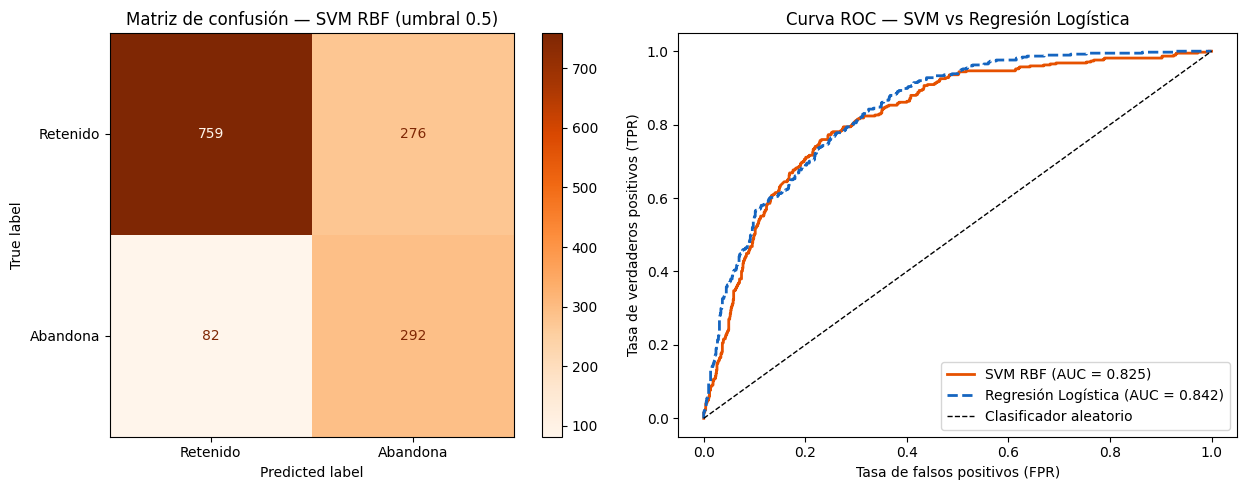

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Matriz de confusión ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=["Retenido", "Abandona"],
    cmap="Oranges",
    ax=axes[0]
)
axes[0].set_title("Matriz de confusión — SVM RBF (umbral 0.5)")

# --- Curva ROC: SVM vs Regresión Logística ---
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)

axes[1].plot(fpr_svm, tpr_svm, lw=2, color="#e65100",
             label=f"SVM RBF (AUC = {auc_svm:.3f})")
axes[1].plot(fpr, tpr, lw=2, color="#1565c0", linestyle="--",
             label=f"Regresión Logística (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
axes[1].set_xlabel("Tasa de falsos positivos (FPR)")
axes[1].set_ylabel("Tasa de verdaderos positivos (TPR)")
axes[1].set_title("Curva ROC — SVM vs Regresión Logística")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

#### Interpretación de la matriz de confusión — SVM (valores reales)

|  | **Predicho: Retenido** | **Predicho: Abandona** |
|---|---|---|
| **Real: Retenido** | **VN = 759** | **FP = 276** |
| **Real: Abandona** | **FN = 82** | **VP = 292** |

- **292 abandonos correctamente detectados** de 374 reales → recall del 78 % en la clase crítica.
- **82 falsos negativos:** clientes que se van sin ser detectados — el error más costoso. Representa 1 de cada 4.5 clientes que abandonan pasando desapercibidos.
- **276 falsas alarmas (FP):** clientes retenidos marcados erróneamente como churn. A umbral 0.5, el SVM genera 3.4 veces más falsas alarmas (276) que abandonos no detectados (82), consecuencia directa del `class_weight='balanced'`.
- **Accuracy = 74.6 %:** Métrica engañosa por el desbalance de clases; un clasificador trivial que siempre predice "Retenido" alcanzaría el 73.5 %, por lo que la ganancia real del SVM es modesta en accuracy.

> **Ajuste de umbral:** Si el coste de un FN supera al de un FP (lo habitual en retención de clientes), reducir el umbral de 0.5 a ~0.3 aumentaría el recall a costa de más FP, lo que puede resultar más rentable para el negocio.

---

#### Interpretación de la curva ROC comparativa

**AUC SVM RBF = 0.8248** vs **AUC Regresión Logística = 0.8417** — diferencia de **–0.0169 a favor de LR**.

- La regresión logística supera al SVM RBF con parámetros predeterminados: su curva ROC se sitúa por encima de la del SVM en la mayor parte del recorrido.
- Una diferencia de 0.017 en AUC es modesta pero real: en un conjunto de prueba de 1 409 ejemplos corresponde a que, en promedio, la LR ordena correctamente ~24 pares más por cada 1 000 comparaciones aleatorias entre un churn y un no-churn.
- **¿Por qué LR supera al SVM con valores por defecto?** El dataset tiene 30 dimensiones y las relaciones dominantes son en su mayoría **lineales** (tipo de contrato, servicio de internet, cargos mensuales). El kernel RBF con $\gamma=\texttt{scale}$ modela la similitud de forma muy local y puede estar capturando ruido en lugar de señal. La optimización de $C$ y $\gamma$ es necesaria para que el SVM aproveche su potencial no lineal.

---

### 5.3 Interpretación de los pesos — SVM lineal

El kernel RBF no produce coeficientes directamente interpretables (la decisión se construye en un espacio de alta dimensión implícito). Para obtener pesos interpretables se entrena un **SVM con kernel lineal** ($K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$), que sí expone el vector $\mathbf{w}$ del hiperplano de separación directamente en el espacio original de características.

> **Nota:** Los pesos $w_j$ del SVM lineal tienen una interpretación geométrica: indican la contribución de cada característica a la **distancia con respecto al hiperplano de decisión**. A diferencia de los coeficientes logísticos (que se interpretan como log-odds), aquí los pesos determinan la orientación del margen máximo. Un $w_j$ grande positivo empuja la predicción hacia "Abandona"; un $w_j$ negativo la empuja hacia "Retenido".

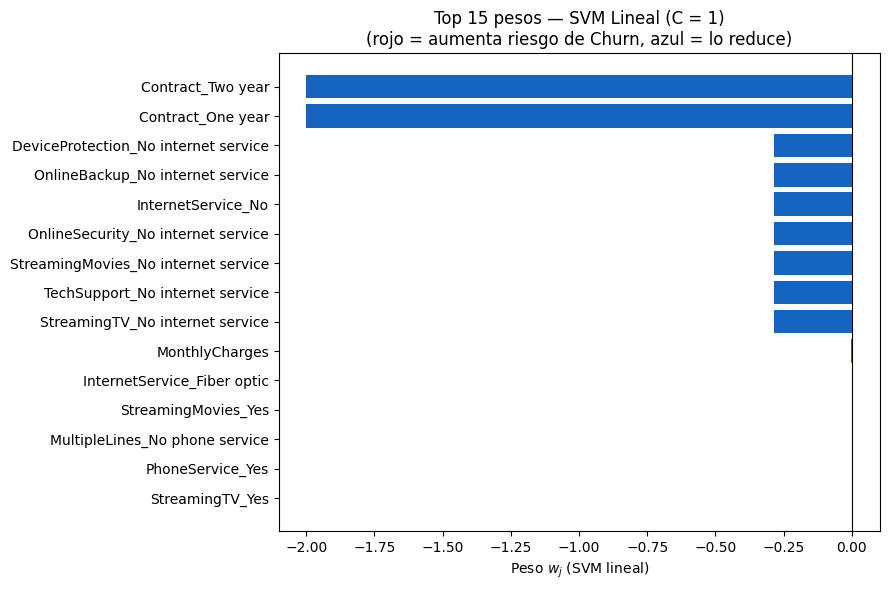

Comparación kernel lineal vs RBF en conjunto de prueba:
  Lineal  — F1: 0.5876
  RBF     — F1: 0.6200


In [10]:
from sklearn.metrics import f1_score

# SVM lineal para obtener pesos interpretables (mismos datos ya estandarizados)
svm_lin = SVC(
    kernel="linear",
    C=1.0,
    class_weight="balanced",
    random_state=42
)
svm_lin.fit(X_train, y_train)

# Top 15 características por magnitud de peso
coef_df_svm = pd.DataFrame({
    "Característica": X_train.columns,
    "Coeficiente":    svm_lin.coef_[0]
}).sort_values("Coeficiente", key=abs, ascending=False).head(15)

plt.figure(figsize=(9, 6))
colors_svm = ["#d32f2f" if c > 0 else "#1565c0" for c in coef_df_svm["Coeficiente"]]
plt.barh(coef_df_svm["Característica"], coef_df_svm["Coeficiente"], color=colors_svm)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Peso $w_j$ (SVM lineal)")
plt.title("Top 15 pesos — SVM Lineal (C = 1)\n(rojo = aumenta riesgo de Churn, azul = lo reduce)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Comparación rápida de rendimiento: lineal vs RBF en conjunto de prueba
y_pred_lin = svm_lin.predict(X_test)
print("Comparación kernel lineal vs RBF en conjunto de prueba:")
print(f"  Lineal  — F1: {f1_score(y_test, y_pred_lin):.4f}")
print(f"  RBF     — F1: {f1_score(y_test, y_pred_svm):.4f}")

### 5.4 Validación cruzada del modelo SVM base

Para obtener una estimación robusta del desempeño del SVM —y poder compararlo directamente con la línea base de regresión logística— se realiza la misma **validación cruzada estratificada de 5 pliegues** sobre el conjunto de entrenamiento completo, usando idéntica partición (`cv` ya definido en la sección 4.4).

In [11]:
cv_auc_svm = cross_val_score(svm_rbf, X_train, y_train, cv=cv, scoring="roc_auc")
cv_f1_svm  = cross_val_score(svm_rbf, X_train, y_train, cv=cv, scoring="f1")

print("Validación cruzada 5-fold — SVM base (RBF, C=1)")
print(f"  AUC-ROC : {cv_auc_svm.mean():.4f} ± {cv_auc_svm.std():.4f}")
print(f"  F1      : {cv_f1_svm.mean():.4f}  ± {cv_f1_svm.std():.4f}")
print()
print("─" * 55)
print("Comparación directa — Regresión Logística vs SVM")
print("─" * 55)
print(f"{'Métrica':<12} {'LR (base)':>15} {'SVM RBF (base)':>18}")
print(f"{'AUC-ROC':<12} {'0.8454 ± 0.0126':>15} {f'{cv_auc_svm.mean():.4f} ± {cv_auc_svm.std():.4f}':>18}")
print(f"{'F1-score':<12} {'0.6298 ± 0.0220':>15} {f'{cv_f1_svm.mean():.4f} ± {cv_f1_svm.std():.4f}':>18}")

Validación cruzada 5-fold — SVM base (RBF, C=1)
  AUC-ROC : 0.8283 ± 0.0103
  F1      : 0.6230  ± 0.0251

───────────────────────────────────────────────────────
Comparación directa — Regresión Logística vs SVM
───────────────────────────────────────────────────────
Métrica            LR (base)     SVM RBF (base)
AUC-ROC      0.8454 ± 0.0126    0.8283 ± 0.0103
F1-score     0.6298 ± 0.0220    0.6230 ± 0.0251


### Resultados de la validación cruzada — SVM base (RBF, C=1)

| Métrica | SVM RBF | Regresión Logística | Diferencia |
|---|---|---|---|
| **AUC-ROC** | **0.8283 ± 0.0103** | 0.8454 ± 0.0126 | –0.0171 |
| **F1-score** | **0.6230 ± 0.0251** | 0.6298 ± 0.0220 | –0.0068 |

#### Interpretación

**AUC-ROC SVM = 0.8283 vs LR = 0.8454 (–0.0171):** El SVM con kernel RBF y parámetros predeterminados es **inferior** a la regresión logística base. La diferencia de 0.017 supera la desviación estándar del SVM (±0.0103), por lo que no es atribuible a variabilidad aleatoria entre pliegues: es una señal real de que $C=1$ y $\gamma=\texttt{scale}$ no son óptimos para este dataset.

**F1 SVM = 0.6230 vs LR = 0.6298 (–0.0068):** La brecha en F1 es mucho más pequeña y cae dentro de ±1 desviación estándar de ambos modelos, lo que indica que en la **detección de abandonos** los dos modelos son prácticamente equivalentes con hiperparámetros por defecto.

**Estabilidad entre pliegues:** La desviación estándar del SVM (±0.0103 en AUC) es ligeramente menor que la de LR (±0.0126), lo que muestra que el SVM es más consistente entre particiones en términos de discriminación global. Sin embargo, en F1 el SVM es más variable (±0.0251 vs ±0.0220), lo que sugiere que su frontera de decisión es más sensible a la composición de cada pliegue.

#### Diagnóstico

La combinación de tres señales apunta al mismo diagnóstico:

| Señal | Valor | Diagnóstico |
|---|---|---|
| AUC en prueba (SVM < LR) | 0.8248 vs 0.8417 | Parámetros subóptimos |
| AUC en CV (SVM < LR) | 0.8283 vs 0.8454 | No es sobreajuste al test set |
| Vectores de soporte | 53.8 % del train | Modelo sobreregularizado ($C$ demasiado pequeño) |

Con $C=1$, el margen es demasiado amplio: el SVM acepta muchas violaciones, lo que equivale a una regularización fuerte que impide ajustarse a las estructuras del problema. Incrementar $C$ y afinar $\gamma$ es el camino natural para que el SVM iguale o supere a la regresión logística.

#### Línea base SVM para la optimización

- **AUC-ROC SVM base: 0.8283 ± 0.0103**
- **F1 SVM base: 0.6230 ± 0.0251**

Un modelo SVM optimizado deberá superar estos valores —idealmente por encima de 0.8386 en AUC y 0.6481 en F1 (media + 1σ)— para considerarse una mejora real respecto al SVM con hiperparámetros predeterminados.